In [41]:
# !pip install anomalib
# !pip install matplotlib
# !pip install numpy
# !pip install tensorboard
# !pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu128
# !pip install kaggle

In [ ]:
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as torch_f
from torch.optim.lr_scheduler import MultiStepLR

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from anomalib.metrics.aupro import _AUPRO as DirectAUPRO
from anomalib.models.image.supersimplenet.loss import SSNLoss
from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel

# import warnings
# warnings.filterwarnings('ignore')

In [ ]:
# CUDA/kernel guard
# CUDA/kernel guard. Run before training to make sure this notebook uses my_env with CUDA PyTorch.
import sys
import torch

print("Python executable:", sys.executable)
print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))

assert "+cu128" in torch.__version__, "Expected CUDA 12.8 PyTorch wheel, e.g. torch==2.7.1+cu128"
assert torch.cuda.is_available(), "CUDA is not visible from this notebook kernel"

# Конфигурация

Основные метрики качества: `image_roc_auc_raw` для image-level detection и `pixel_aupro` для localization/segmentation. Они используются для валидации и финальной оценки.


# Senior ML review notes

Вопросы к исходному ноутбуку и итоговая валидация:

1. `predict_with_augmentations` назывался TTA, но фактически использовал только исходное изображение, а flip-код был закомментирован. Это не баг в метрике, но источник путаницы. Меняю на `predict_anomaly_map`, где явно видно: один forward, `sigmoid` для pixel logits, optional resize.
2. `torch.sigmoid(output.anomaly_map)` выглядит подозрительно только на первый взгляд. Для SSN segmentation decoder обычно возвращает logits, а `SSNLoss` обучает карту как logits against target mask. Для визуализации и pixel metrics нужна probability-like карта, поэтому sigmoid оставляем, но делаем это в одной функции и не смешиваем с `+ 1` или TTA.
3. Странная карта на normal image частично объясняется визуализацией: matplotlib раньше авторастягивал colormap под min/max конкретной картинки. Даже слабый фон начинал выглядеть ярким. Теперь heatmap фиксируется в диапазоне `vmin=0, vmax=1`, а картинка денормализуется и clamp'ится.
4. Training loss path и validation loss path были реализованы разными путями: train звал `model(images, masks=..., labels=...)`, validation вручную проходил `feature_extractor -> adaptor -> anomaly_generator -> segdec`. Это риск рассинхронизации при изменениях anomalib. Вынесен единый `ssn_training_forward` и используется и в train, и в val loss.
5. `test_classes=[]` в конструкторах датасетов - mutable default argument. Сейчас это не ломало запуск, но это плохая практика и потенциальный источник скрытого состояния. Заменено на `None`.
6. Сохранение целой модели через `torch.save(model, ...)` оставлено для совместимости с уже обученными весами, но дополнительно сохраняется `state_dict`. На будущее лучше грузить архитектуру + state_dict, потому что pickle зависит от версии anomalib и кода.
7. `final_metrics.txt` раньше писал последние значения метрик, хотя возвращалась best model по early stopping. Это может быть не то же самое. Добавлены `best_epoch`, `best_<metric>`; полное переоценивание best model в конце можно добавить отдельно, если нужно сравнивать именно финальную сохраненную модель.

Для предобработки картинок и постобработке карт аномалий

In [43]:
dataset_path = os.path.join("../datasets", "MVTecAD")
class_name = "hazelnut"
test_groups = ["crack", "cut", "hole", "good"]
image_size = 256
quality_metric_names = ["image_roc_auc_raw", "pixel_aupro"]


In [ ]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.9, 1.0), ratio=(1, 1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_mask_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ])


def denormalize_image(tensor):
    denormalize = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )
    return torch.clamp(denormalize(tensor.detach().cpu()), 0.0, 1.0)


def show_tensor(tensor):
    transforms.ToPILImage()(tensor.detach().cpu()).show()


def postprocess_anomaly_map(anomaly_map, true_img_size):
    while anomaly_map.ndim < 4:
        anomaly_map = anomaly_map.unsqueeze(0)

    upsampled_mask = torch_f.interpolate(
        anomaly_map,
        size=true_img_size,
        mode="bilinear",
        align_corners=False,
    )
    return upsampled_mask.squeeze()

In [45]:
# path = os.path.join(dataset_path, class_name, "test", test_groups[0], "003.png")
# print(path)
# img = Image.open(path).convert('RGB')
# img = get_transformer(256)(img)
# print(img.shape)
# # img = img[0, :, :]
# img = postprocess_anomaly_map(img.unsqueeze(0), true_img_size=(900, 900))
# print(img.shape)
# print(img.max())
# print(img.dtype)
# show_tensor(img)

Датасеты

In [ ]:
class Train_Dataset(Dataset):
    def __init__(self, root_dir, category, transform=None, split="train", good_class_dir="good"):
        self.root_dir = os.path.join(root_dir, category, split)
        self.transform = transform
        self.image_paths = []

        good_path = os.path.join(self.root_dir, good_class_dir)
        if os.path.isdir(good_path):
            for img_name in sorted(os.listdir(good_path)):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.image_paths.append(os.path.join(good_path, img_name))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


class Segmentation_Dataset(Dataset):
    def __init__(
        self,
        root_dir,
        category,
        img_transform=None,
        mask_transform=None,
        imgs_dir="test",
        test_classes=None,
        masks_dir="ground_truth",
        good_class_dir="good",
        strict_masks=True,
    ):
        self.img_transform = img_transform
        self.mask_transform = mask_transform
        self.base_transform = transforms.ToTensor()
        test_classes = set(test_classes or [])

        imgs_path = os.path.join(root_dir, category, imgs_dir)
        masks_path = os.path.join(root_dir, category, masks_dir)
        image_paths = []
        mask_paths = []
        missing_masks = []

        for defect_type in sorted(os.listdir(imgs_path)):
            if test_classes and defect_type not in test_classes:
                continue
            if defect_type == good_class_dir:
                continue

            class_path = os.path.join(imgs_path, defect_type)
            if not os.path.isdir(class_path):
                continue

            mask_class_path = os.path.join(masks_path, defect_type)
            for img_name in sorted(os.listdir(class_path)):
                if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                image_path = os.path.join(class_path, img_name)
                stem, ext = os.path.splitext(img_name)
                candidate = os.path.join(mask_class_path, f"{stem}_mask{ext}")
                mask_path = candidate if os.path.exists(candidate) else None

                if mask_path is None and os.path.isdir(mask_class_path):
                    mask_stem = f"{stem}_mask"
                    for mask_name in sorted(os.listdir(mask_class_path)):
                        if os.path.splitext(mask_name)[0] == mask_stem:
                            mask_path = os.path.join(mask_class_path, mask_name)
                            break

                if mask_path is None:
                    missing_masks.append(image_path)
                    continue

                image_paths.append(image_path)
                mask_paths.append(mask_path)

        if missing_masks and strict_masks:
            preview = "\n".join(missing_masks[:5])
            extra = "" if len(missing_masks) <= 5 else f"\n... and {len(missing_masks) - 5} more"
            raise FileNotFoundError(f"Masks were not found for {len(missing_masks)} images:\n{preview}{extra}")

        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")

        image = self.img_transform(image) if self.img_transform else self.base_transform(image)
        mask = self.mask_transform(mask) if self.mask_transform else self.base_transform(mask)
        return image, mask


class Classification_Dataset(Dataset):
    def __init__(self, root_dir, category, img_transform=None, imgs_dir="test", test_classes=None, good_class_dir="good"):
        self.img_transform = img_transform
        self.base_transform = transforms.ToTensor()
        test_classes = set(test_classes or [])

        imgs_path = os.path.join(root_dir, category, imgs_dir)
        image_paths = []
        image_labels = []
        for defect_type in sorted(os.listdir(imgs_path)):
            if test_classes and defect_type not in test_classes:
                continue
            class_path = os.path.join(imgs_path, defect_type)
            if not os.path.isdir(class_path):
                continue
            for img_name in sorted(os.listdir(class_path)):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    image_paths.append(os.path.join(class_path, img_name))
                    image_labels.append(0 if defect_type == good_class_dir else 1)

        self.images = image_paths
        self.labels = image_labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        image = self.img_transform(image) if self.img_transform else self.base_transform(image)
        return image, label

In [47]:
# train_dataset = Train_Dataset(dataset_path, class_name, get_augmented_transformer(256))
train_dataset = Train_Dataset(dataset_path, class_name, transform=get_transformer(image_size))
print(f"Train dataset size: {len(train_dataset)}")

segmentation_dataset = Segmentation_Dataset(dataset_path, class_name, img_transform=get_transformer(image_size), mask_transform=get_mask_transformer(image_size), test_classes=test_groups)
segmentation_val_dataset, segmentation_test_dataset = train_test_split(segmentation_dataset, test_size=0.6, random_state=42, shuffle=True)
print(f"Segmentation dataset size: validation - {len(segmentation_val_dataset)}, test - {len(segmentation_test_dataset)}")

classification_dataset = Classification_Dataset(dataset_path, class_name, img_transform=get_transformer(image_size), test_classes=test_groups)
classification_val_dataset, classification_test_dataset = train_test_split(classification_dataset, stratify=[i[1] for i in classification_dataset], test_size=0.6, random_state=42, shuffle=True)
print(f"Classification dataset size: validation - {len(classification_val_dataset)}, test - {len(classification_test_dataset)}")

Train dataset size: 391
Segmentation dataset size: validation - 21, test - 32
Classification dataset size: validation - 37, test - 56


# Метрики качества

In [ ]:
def img2mask(img):
    mask = img.detach().cpu() if isinstance(img, torch.Tensor) else img
    mask = mask if mask.ndim <= 2 else mask.squeeze()
    if mask.ndim == 3:
        mask = mask[0, :, :]
    if mask.ndim != 2:
        raise ValueError(f"Expected a 2D mask after squeeze, got shape {tuple(mask.shape)}")
    return mask


def pixel_aupro(pred_anomaly_maps, true_masks, fpr_limit=0.3, num_thresholds=100):
    preds = torch.stack([img2mask(pred).float().cpu() for pred in pred_anomaly_maps])
    targets = torch.stack([(img2mask(mask) > 0.5).long().cpu() for mask in true_masks])
    if targets.max().item() == targets.min().item():
        return float("nan")
    metric = DirectAUPRO(fpr_limit=fpr_limit, num_thresholds=num_thresholds)
    return float(metric(preds, targets).detach().cpu().item())


def plot_training_curves(metrics, metric_names, log_dir, plot_name, log_y=False):
    os.makedirs(log_dir, exist_ok=True)
    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    if log_y:
        plt.yscale("log")
    plt.title("Training metrics")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, plot_name))
    plt.show()


def visualize_results(original_image, anomaly_map, true_mask=None, score=None, figsize=None, alpha=0.7, cmap="jet"):
    original_image = denormalize_image(original_image.squeeze())
    original_pil = transforms.ToPILImage()(original_image)

    anomaly_map = img2mask(anomaly_map).float().cpu().numpy()
    has_mask = true_mask is not None
    ncols = 3 if has_mask else 2
    if figsize is None:
        figsize = (5 * ncols, 5)

    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    if ncols == 1:
        axes = [axes]

    axes[0].imshow(original_pil)
    title = "Original image"
    if score is not None:
        title += f" | score={score:.4f}"
    axes[0].set_title(title, fontsize=14)
    axes[0].axis("off")

    anomaly_axis_index = 1
    if has_mask:
        true_mask = img2mask(true_mask).float().cpu().numpy()
        axes[1].imshow(original_pil)
        heatmap = axes[1].imshow(true_mask, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
        axes[1].set_title("Input + True Mask", fontsize=14)
        axes[1].axis("off")
        plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
        anomaly_axis_index = 2

    axes[anomaly_axis_index].imshow(original_pil)
    heatmap = axes[anomaly_axis_index].imshow(anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    axes[anomaly_axis_index].set_title("Input + Anomaly Map", fontsize=14)
    axes[anomaly_axis_index].axis("off")
    plt.colorbar(heatmap, ax=axes[anomaly_axis_index], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Обучение модели

In [49]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")

cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [ ]:
def freeze_feature_extractor(model):
    frozen_params_num = 0
    if hasattr(model, "feature_extractor"):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")


def get_trainable_parameters(model):
    train_params_num = 0
    for _, param in model.named_parameters():
        if param.requires_grad:
            train_params_num += param.numel()
    print(f"Trainable parameters: {train_params_num}")


def ssn_training_forward(model, images, masks=None, labels=None):
    if masks is None:
        masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=images.device)
    if labels is None:
        labels = torch.zeros((images.shape[0],), device=images.device)

    features = model.feature_extractor(images)
    adapted = model.adaptor(features)
    target_mask = model.downsample_mask(masks, *features.shape[-2:])
    target_label = labels.to(torch.float32)
    train_features, target_mask, target_label = model.anomaly_generator(adapted, target_mask, target_label)
    pred_map, pred_score = model.segdec(train_features)
    return pred_map, pred_score, target_mask, target_label


def predict_anomaly_map(model, img, true_img_size=None, apply_sigmoid=True):
    model.eval()
    with torch.no_grad():
        output = model(img)
        anomaly_map = output.anomaly_map
        if apply_sigmoid:
            anomaly_map = torch.sigmoid(anomaly_map)
        if true_img_size is not None:
            anomaly_map = postprocess_anomaly_map(anomaly_map, true_img_size=true_img_size)
    return anomaly_map


def predict_image_score(model, img, apply_sigmoid=False):
    model.eval()
    with torch.no_grad():
        score = model(img).pred_score.detach().view(-1)[0]
        if apply_sigmoid:
            score = torch.sigmoid(score)
    return float(score.cpu().item())

In [ ]:
num_good_in_classification_test = sum(1 for _, label in classification_test_dataset if label == 0)
print(f"Good images in classification test: {num_good_in_classification_test}")

In [ ]:
def train_ssn_with_validation(
    model,
    train_dataset,
    segmentation_dataset=None,
    classification_dataset=None,
    num_epochs=50,
    learning_rate=1e-3,
    weight_decay=1e-3,
    device=device,
    log_interval=1,
    log_dir="../experiments",
    freeze_extractor=True,
    batch_size=8,
    num_workers=0,
    resume_from_checkpoint=True,
    early_stopping_patience=10,
    early_stopping_metric="pixel_aupro",
    early_stopping_mode="max",
):
    model = model.to(device)
    criterion = SSNLoss()
    os.makedirs(log_dir, exist_ok=True)
    checkpoints_dir = os.path.join(log_dir, "middle_logs")
    os.makedirs(checkpoints_dir, exist_ok=True)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters number: {total_params}")
    if freeze_extractor:
        freeze_feature_extractor(model)
    get_trainable_parameters(model)

    optimizer = optim.AdamW([
        {"params": model.adaptor.parameters(), "lr": learning_rate},
        {"params": model.segdec.parameters(), "lr": learning_rate * 2, "weight_decay": weight_decay},
    ])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.8)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    best_score = -float("inf") if early_stopping_mode == "max" else float("inf")
    epochs_without_improvement = 0
    best_model_state = None
    best_epoch = None

    checkpoint_path = os.path.join(log_dir, "last_checkpoint.pth")
    legacy_checkpoint_path = os.path.join(checkpoints_dir, "checkpoint.pth")
    if resume_from_checkpoint and not os.path.exists(checkpoint_path) and os.path.exists(legacy_checkpoint_path):
        checkpoint_path = legacy_checkpoint_path

    start_epoch = 0
    epoch_scores = {"Train_Loss": []}
    if resume_from_checkpoint and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        epoch_scores = checkpoint["epoch_scores"]
        best_score = checkpoint.get("best_score", best_score)
        best_epoch = checkpoint.get("best_epoch", best_epoch)
        print(f"Resuming from epoch {start_epoch + 1}")
    else:
        print("Starting training from scratch...")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch + 1}/{num_epochs}", leave=False):
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)

            optimizer.zero_grad()
            pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
            loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        epoch_scores["Train_Loss"].append(avg_train_loss)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            if classification_dataset is not None:
                epoch_scores.setdefault("Validation_Loss", [])
                total_val_loss = 0.0
                good_val_len = 0
                for i in tqdm(range(len(classification_dataset)), desc="Good Val Loss", leave=False):
                    img, true_label = classification_dataset[i]
                    if true_label != 0:
                        continue
                    img = img.unsqueeze(0).to(device)
                    pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, img)
                    loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
                    total_val_loss += loss.item()
                    good_val_len += 1
                epoch_scores["Validation_Loss"].append(total_val_loss / max(1, good_val_len))

            if segmentation_dataset is not None:
                epoch_scores.setdefault("pixel_aupro", [])
                anomaly_maps = []
                true_masks = []
                for i in tqdm(range(len(segmentation_dataset)), desc="Segmentation Val", leave=False):
                    img, true_mask = segmentation_dataset[i]
                    img = img.unsqueeze(0).to(device)
                    anomaly_map = predict_anomaly_map(
                        model,
                        img,
                        true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                        apply_sigmoid=True,
                    )
                    anomaly_maps.append(anomaly_map)
                    true_masks.append(true_mask)
                epoch_scores["pixel_aupro"].append(pixel_aupro(anomaly_maps, true_masks))

            if classification_dataset is not None:
                epoch_scores.setdefault("image_roc_auc_raw", [])
                predicted_scores = []
                true_labels = []
                for i in tqdm(range(len(classification_dataset)), desc="Classification Val", leave=False):
                    img, true_label = classification_dataset[i]
                    img = img.unsqueeze(0).to(device)
                    predicted_scores.append(predict_image_score(model, img, apply_sigmoid=False))
                    true_labels.append(true_label)
                epoch_scores["image_roc_auc_raw"].append(roc_auc_score(true_labels, predicted_scores))

        if (epoch + 1) % log_interval == 0:
            print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.6f}")
            for metric_name, values in epoch_scores.items():
                if metric_name != "Train_Loss" and values:
                    print(f"Epoch {epoch + 1} | {metric_name}: {values[-1]:.6f}")

            checkpoint_metrics_path = os.path.join(checkpoints_dir, "checkpoints_metrics.txt")
            write_mode = "w" if not os.path.exists(checkpoint_metrics_path) or (not resume_from_checkpoint and epoch == 0) else "a"
            with open(checkpoint_metrics_path, write_mode) as f:
                f.write(f"Epoch {epoch + 1}:\n")
                for metric_name, metric in epoch_scores.items():
                    f.write(f"{metric_name}: {metric[-1]}\n")
                f.write("\n")

        should_stop = False
        if early_stopping_metric in epoch_scores:
            current_score = epoch_scores[early_stopping_metric][-1]
            is_better = (
                (early_stopping_mode == "max" and current_score > best_score) or
                (early_stopping_mode == "min" and current_score < best_score)
            )
            if is_better:
                best_score = current_score
                epochs_without_improvement = 0
                best_model_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
            else:
                epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                should_stop = True

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch_scores": epoch_scores,
            "learning_rate": learning_rate,
            "best_score": best_score,
            "best_epoch": best_epoch,
        }, checkpoint_path)

        if should_stop:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (epoch {best_epoch}, {early_stopping_metric}: {best_score:.4f})")
    else:
        print("No early stopping metric found - using final model")

    torch.save(model.state_dict(), os.path.join(log_dir, "trained_model_weights.pth"))
    torch.save(model, os.path.join(log_dir, "trained_model.pth"))
    print(f"Best model and last checkpoint saved to {log_dir}")

    with open(os.path.join(log_dir, "final_metrics.txt"), "w") as f:
        for metric_name, metric in epoch_scores.items():
            f.write(f"{metric_name}: {metric[-1]}\n")
        f.write(f"best_epoch: {best_epoch}\n")
        f.write(f"best_{early_stopping_metric}: {best_score}\n")

    if "Train_Loss" in epoch_scores and "Validation_Loss" in epoch_scores:
        plot_training_curves(
            [epoch_scores["Train_Loss"], epoch_scores["Validation_Loss"]],
            ["Train_Loss", "Validation_Loss"],
            log_dir,
            "Losses.png",
        )

    metric_curves = {k: v for k, v in epoch_scores.items() if k not in {"Train_Loss", "Validation_Loss"}}
    if metric_curves:
        plot_training_curves(list(metric_curves.values()), list(metric_curves.keys()), log_dir, "validation_metrics.png")

    return model

In [53]:
torch.cuda.empty_cache()

In [54]:
logs_path = "ssn_baseline"
experiment_try = "try_1"
log_dir = os.path.join("../experiments", class_name, logs_path, experiment_try)
print(os.path.abspath(log_dir))


c:\Users\AERO\Desktop\master_work\Experiments\experiments\hazelnut\ssn_baseline\try_1


Total parameters number: 33719363
Parameters frozen: 24862528
Trainable parameters: 8856835
Starting training from scratch...


Epoch 4/70 | Train Loss: 1.062935


Epoch 4/70 | Val Loss: 0.822324


Epoch 4 | Pixel AUPRO: 0.5343


Epoch 4 | Image ROC AUC: 0.5625


...

Epoch 48 | Image ROC AUC: 1.0000


Epoch 52/70 | Train Loss: 0.071390


Epoch 52/70 | Val Loss: 0.080115


Epoch 52 | Pixel AUPRO: 0.9291


Epoch 52 | Image ROC AUC: 1.0000
Early stopping triggered at epoch 52
Loaded best model (epoch 40, score: 0.9379)
Best model and last checkpoint saved to ../experiments\hazelnut\ssn_baseline\try_1


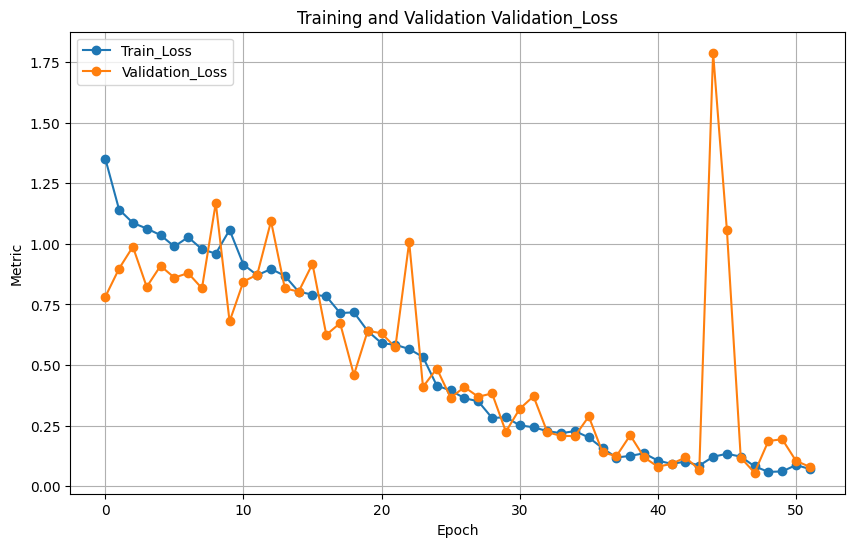

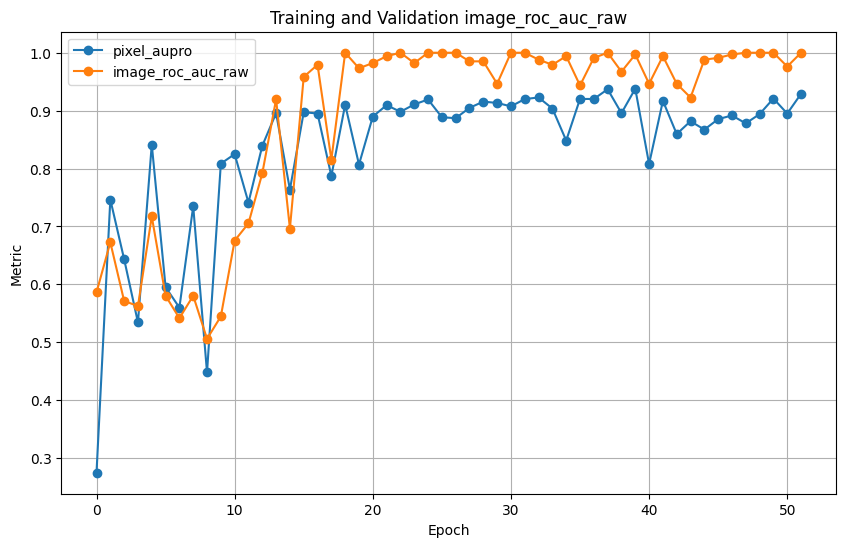

In [55]:
model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True
    )

trained_model = train_ssn_with_validation(
    model=model,
    train_dataset=train_dataset,
    segmentation_dataset=segmentation_val_dataset,
    classification_dataset=classification_val_dataset,
    num_epochs=70,
    learning_rate=1e-4,
    weight_decay=1e-5,
    device=device,
    log_interval=4,
    log_dir=log_dir,
    batch_size=10,
    resume_from_checkpoint=False,
    freeze_extractor=True,
    early_stopping_patience=12,
    early_stopping_metric="pixel_aupro",
    early_stopping_mode="max"
)

# Тестирование лучшей обученной модели

In [56]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")

cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [ ]:
# Backward-compatible alias for old notebook cells. New code should call predict_anomaly_map directly.
def predict_with_augmentations(model, img, true_img_size=None):
    return predict_anomaly_map(model, img, true_img_size=true_img_size, apply_sigmoid=True)

In [ ]:
# Load the trained model from the selected try_N folder.
best_model_path = os.path.join(log_dir, "trained_model.pth")
best_trained_model = torch.load(best_model_path, map_location=device, weights_only=False)
best_trained_model.to(device)
best_trained_model.eval()

# Segmentation/localization test.
anomaly_maps = []
true_masks = []
with torch.no_grad():
    for i in tqdm(range(len(segmentation_test_dataset)), desc="Segmentation Test", leave=False):
        img, true_mask = segmentation_test_dataset[i]
        img = img.unsqueeze(0).to(device)
        anomaly_map = predict_anomaly_map(
            best_trained_model,
            img,
            true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
            apply_sigmoid=True,
        )
        anomaly_maps.append(anomaly_map)
        true_masks.append(true_mask)

        if i % 4 == 0:
            visualize_results(img, anomaly_map, true_mask=true_mask)

pixel_aupro_score = pixel_aupro(anomaly_maps, true_masks)

# Image-level detection test.
predicted_scores = []
true_labels = []
with torch.no_grad():
    for i in tqdm(range(len(classification_test_dataset)), desc="Classification Test", leave=False):
        img, true_label = classification_test_dataset[i]
        img = img.unsqueeze(0).to(device)

        anomaly_map = predict_anomaly_map(best_trained_model, img, apply_sigmoid=True)
        img_score = predict_image_score(best_trained_model, img, apply_sigmoid=False)

        predicted_scores.append(img_score)
        true_labels.append(true_label)
        if true_label == 0:
            visualize_results(img, anomaly_map, score=img_score)

image_roc_auc_raw = roc_auc_score(true_labels, predicted_scores)

test_metrics = {
    "image_roc_auc_raw": image_roc_auc_raw,
    "pixel_aupro": pixel_aupro_score,
}
with open(os.path.join(log_dir, "test_metrics.txt"), "w") as f:
    for metric_name in quality_metric_names:
        f.write(f"{metric_name}: {test_metrics[metric_name]}\n")

print(f"Image ROC AUC: {image_roc_auc_raw}")
print(f"Pixel AUPRO: {pixel_aupro_score}")